In [131]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

In [132]:
# We'll use the SMOTE version
df_train = pd.read_csv("diabetes_train_smote_normalized.csv")
df_test = pd.read_csv("diabetes_test_normalized.csv")

In [133]:
X_train = df_train.drop(columns=['class'])
y_train = df_train['class']
X_test = df_test.drop(columns=['class'])
y_test = df_test['class']

In [134]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the encoder
le = LabelEncoder()

# 2. Fit and transform the gender column
# We do this for the whole column to ensure consistency
X_train['gender'] = le.fit_transform(X_train['gender'])
X_test['gender'] = le.transform(X_test['gender'])


In [ ]:
# Initialize the model
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict
y_pred = dt_model.predict(X_test)

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           N       1.00      1.00      1.00        19
           P       1.00      0.88      0.93         8
           Y       0.99      1.00      1.00       139

    accuracy                           0.99       166
   macro avg       1.00      0.96      0.98       166
weighted avg       0.99      0.99      0.99       166

Confusion Matrix:
 [[ 19   0   0]
 [  0   7   1]
 [  0   0 139]]


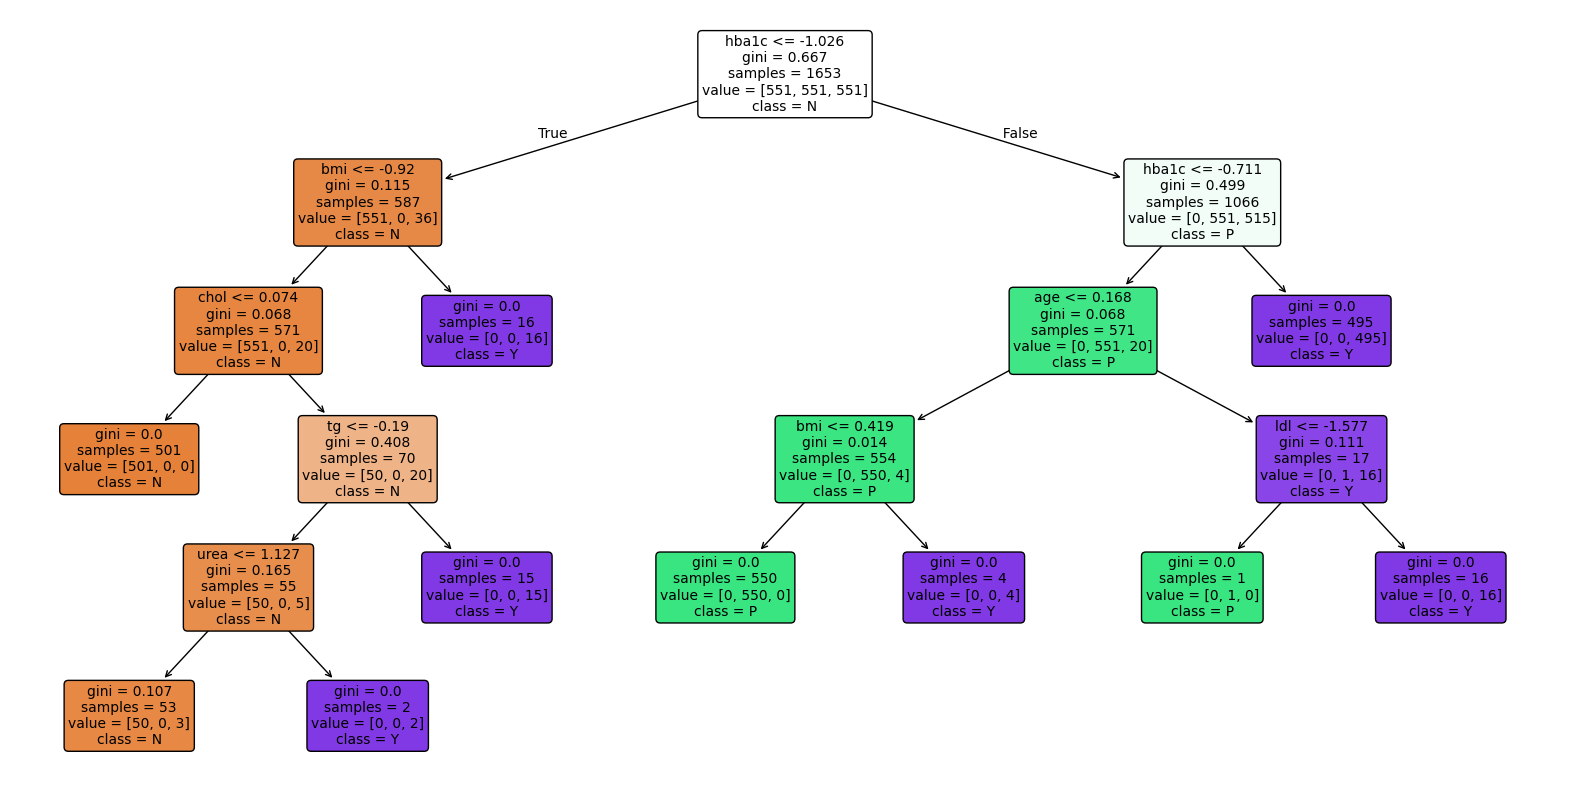

In [136]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X_train.columns, 
          class_names=['N', 'P', 'Y'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()

With disceretization

In [137]:
from sklearn.preprocessing import KBinsDiscretizer

In [138]:
# Choose which columns to discretize (everything except gender and class)
# We exclude 'gender' (binary) and 'class' (target)
features_to_bin = [col for col in X_train.columns if col != 'gender']

# Initialize the Discretizer
# n_bins=5: creates 5 "buckets" for each feature
# encode='ordinal': turns the values into 0, 1, 2, 3, 4
# strategy='kmeans': uses k-means clustering to find the optimal bin edges
kbins = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='kmeans')

# Apply to training and testing data
X_train_binned = X_train.copy()
X_test_binned = X_test.copy()

X_train_binned[features_to_bin] = kbins.fit_transform(X_train[features_to_bin])
X_test_binned[features_to_bin] = kbins.transform(X_test[features_to_bin])

# Now use these binned dataframes to train the model
dt_model.fit(X_train_binned, y_train)
y_pred_binned = dt_model.predict(X_test_binned)

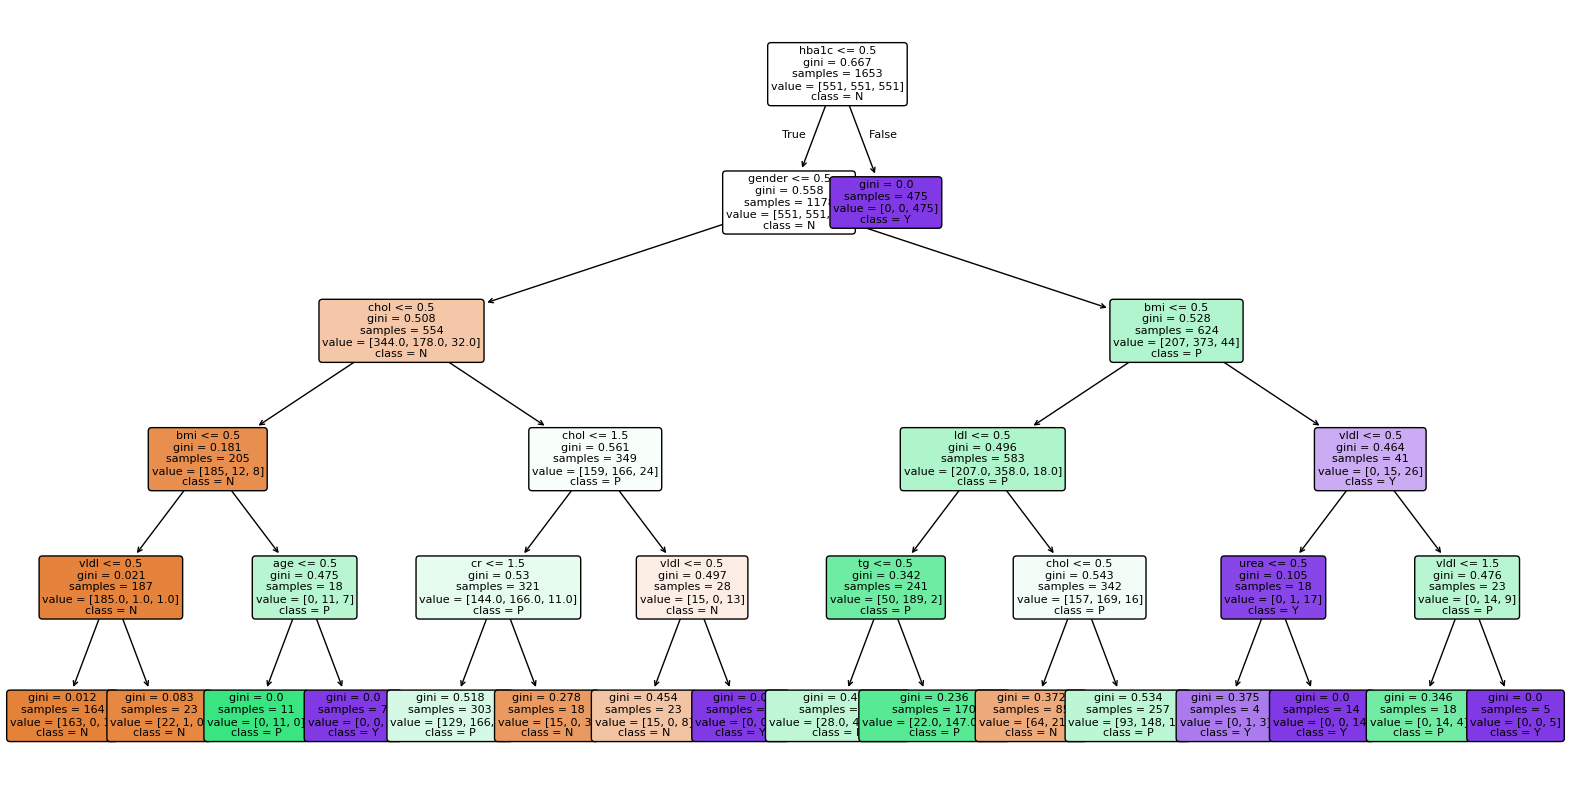

In [142]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X_train_binned.columns, 
          class_names=['N', 'P', 'Y'], 
          filled=True, 
          rounded=True, 
          fontsize=8)
plt.show()

In [140]:
print("Classification Report:\n", classification_report(y_test, y_pred_binned))

Classification Report:
               precision    recall  f1-score   support

           N       1.00      0.42      0.59        19
           P       0.27      0.88      0.41         8
           Y       0.99      0.94      0.97       139

    accuracy                           0.88       166
   macro avg       0.75      0.75      0.66       166
weighted avg       0.96      0.88      0.90       166



In [141]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_binned)
print(cm)

[[  8  11   0]
 [  0   7   1]
 [  0   8 131]]
